In [1]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Dataset, Subset
from torchvision import datasets, transforms, models
from torchvision.models import (
    resnet50, ResNet50_Weights,
    efficientnet_b0, EfficientNet_B0_Weights
)
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

In [2]:
import subprocess
result = subprocess.run([
    "pip", "install", "-q",
    "torch==2.1.0", "torchvision==0.16.0",
    "--index-url", "https://download.pytorch.org/whl/cu118"
], capture_output=True, text=True)
print(result.stdout[-500:] if result.stdout else "OK")
print(result.stderr[-300:] if result.stderr else "")

OK
OR: Could not find a version that satisfies the requirement torch==2.1.0 (from versions: 2.2.0+cu118, 2.2.1+cu118, 2.2.2+cu118, 2.3.0+cu118, 2.3.1+cu118, 2.4.0+cu118, 2.4.1+cu118, 2.5.0+cu118, 2.5.1+cu118, 2.6.0+cu118, 2.7.0+cu118, 2.7.1+cu118)
ERROR: No matching distribution found for torch==2.1.0



In [3]:
import torch
print(torch.cuda.is_available())  
print(torch.cuda.get_device_name(0))  

True
Tesla T4


In [4]:
BASE_DIR  = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
TEST_CSV  = os.path.join(BASE_DIR, "Test.csv")

print("BASE_DIR:", BASE_DIR)
print("Train exists:", os.path.isdir(TRAIN_DIR))
print("Some train subfolders:", os.listdir(TRAIN_DIR)[:10])

BASE_DIR: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
Train exists: True
Some train subfolders: ['7', '17', '19', '22', '2', '35', '23', '10', '5', '36']


In [5]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

In [6]:
train_full = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_full   = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)

num_classes  = len(train_full.classes)
class_to_idx = train_full.class_to_idx
id_to_internal = {int(k): v for k, v in class_to_idx.items()}

print("Кількість класів:", num_classes)
print("Загальна кількість зображень:", len(train_full))

train_size = int(0.8 * len(train_full))
val_size   = len(train_full) - train_size

generator = torch.Generator().manual_seed(42)
indices   = torch.randperm(len(train_full), generator=generator).tolist()

train_indices = indices[:train_size]
val_indices   = indices[train_size:]

train_dataset = Subset(train_full, train_indices)
val_dataset   = Subset(val_full,   val_indices)

print("Train size:", len(train_dataset))
print("Val size:  ", len(val_dataset))

Кількість класів: 43
Загальна кількість зображень: 39209
Train size: 31367
Val size:   7842


In [7]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size,
                          shuffle=False, num_workers=2, pin_memory=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [8]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        self.features = nn.Sequential(
         
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

        
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

           
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

           
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

print("BaselineCNN параметрів:",
      sum(p.numel() for p in BaselineCNN().parameters() if p.requires_grad))

BaselineCNN параметрів: 26102059


In [9]:
resnet_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

for param in resnet_model.parameters():
    param.requires_grad = False

# розморожуємо layer4 і fc
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)

print("ResNet50 — навчуваних параметрів:",
      sum(p.numel() for p in resnet_model.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


ResNet50 — навчуваних параметрів: 15052843


In [10]:

effnet_model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

for param in effnet_model.parameters():
    param.requires_grad = False


for param in effnet_model.features[-1].parameters():
    param.requires_grad = True
for param in effnet_model.features[-2].parameters():
    param.requires_grad = True

effnet_model.classifier[1] = nn.Linear(
    effnet_model.classifier[1].in_features, num_classes
)

print("EfficientNet-B0 — навчуваних параметрів:",
      sum(p.numel() for p in effnet_model.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 188MB/s]

EfficientNet-B0 — навчуваних параметрів: 1184475


In [11]:
def train_model(model, model_name, max_epochs=40, patience=2, min_delta=1e-4):
    print(f"\n{'='*55}")
    print(f"  Навчання: {model_name}")
    print(f"{'='*55}")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4,
        weight_decay=1e-4
    )

    best_val_loss      = float("inf")
    best_state_dict    = None
    epochs_no_improve  = 0

    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    for epoch in range(max_epochs):
       
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train   = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct_train += (preds == labels).sum().item()
            total_train   += labels.size(0)

        avg_train_loss = running_train_loss / len(train_loader)
        train_acc      = correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)

     
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val   = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()
                preds = outputs.argmax(dim=1)
                correct_val += (preds == labels).sum().item()
                total_val   += labels.size(0)

        avg_val_loss = running_val_loss / len(val_loader)
        val_acc      = correct_val / total_val
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}/{max_epochs} | "
            f"train_loss: {avg_train_loss:.4f}, train_acc: {train_acc:.4f} | "
            f"val_loss: {avg_val_loss:.4f}, val_acc: {val_acc:.4f}"
        )

       
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"  No improvement for {epochs_no_improve} epoch(s).")
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}.")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        print("\nLoaded best model weights (minimal val_loss).")

    history = {
        "train_losses": train_losses, "val_losses": val_losses,
        "train_accs":   train_accs,   "val_accs":   val_accs
    }
    return model, history

In [12]:
def plot_history(history, model_name):
    epochs_range = range(1, len(history["train_losses"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_losses"], marker="o", label="Train loss")
    plt.plot(epochs_range, history["val_losses"],   marker="o", label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} — Train vs Val loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_accs"], marker="o", label="Train acc")
    plt.plot(epochs_range, history["val_accs"],   marker="o", label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} — Train vs Val accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


  Навчання: BaselineCNN
Epoch 1/40 | train_loss: 2.1012, train_acc: 0.3920 | val_loss: 0.9790, val_acc: 0.6970
Epoch 2/40 | train_loss: 1.1816, train_acc: 0.6238 | val_loss: 0.5185, val_acc: 0.8440
Epoch 3/40 | train_loss: 0.8272, train_acc: 0.7305 | val_loss: 0.2922, val_acc: 0.9183
Epoch 4/40 | train_loss: 0.6554, train_acc: 0.7857 | val_loss: 0.2360, val_acc: 0.9320
Epoch 5/40 | train_loss: 0.5608, train_acc: 0.8149 | val_loss: 0.1786, val_acc: 0.9476
Epoch 6/40 | train_loss: 0.4951, train_acc: 0.8362 | val_loss: 0.1517, val_acc: 0.9598
Epoch 7/40 | train_loss: 0.4340, train_acc: 0.8559 | val_loss: 0.1327, val_acc: 0.9606
Epoch 8/40 | train_loss: 0.3959, train_acc: 0.8662 | val_loss: 0.1253, val_acc: 0.9639
Epoch 9/40 | train_loss: 0.3687, train_acc: 0.8764 | val_loss: 0.1002, val_acc: 0.9703
Epoch 10/40 | train_loss: 0.3489, train_acc: 0.8842 | val_loss: 0.0869, val_acc: 0.9725
Epoch 11/40 | train_loss: 0.3327, train_acc: 0.8876 | val_loss: 0.0846, val_acc: 0.9725
Epoch 12/40 | tr

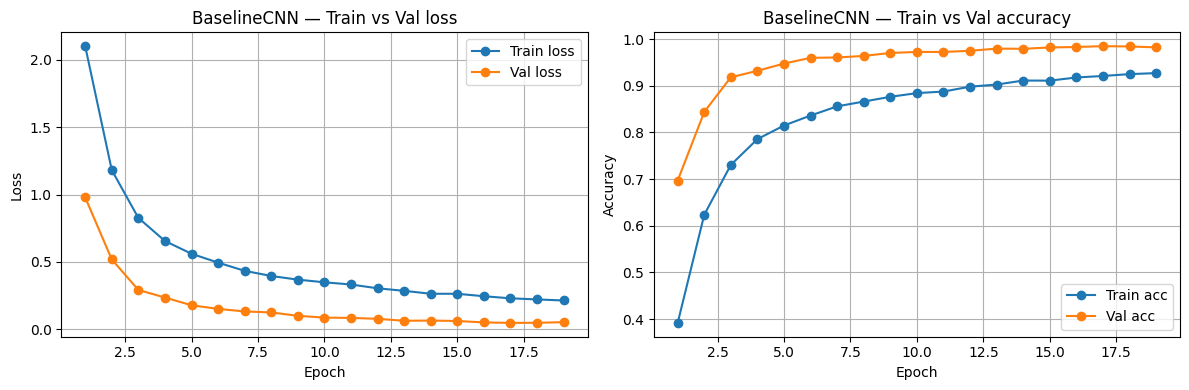

In [13]:
baseline_model, baseline_history = train_model(
    BaselineCNN(num_classes=num_classes), "BaselineCNN"
)
plot_history(baseline_history, "BaselineCNN")
torch.save(baseline_model.state_dict(), "/kaggle/working/baseline_cnn_gtsrb.pth")


  Навчання: ResNet50
Epoch 1/40 | train_loss: 0.4725, train_acc: 0.8656 | val_loss: 0.1109, val_acc: 0.9602
Epoch 2/40 | train_loss: 0.1114, train_acc: 0.9631 | val_loss: 0.0903, val_acc: 0.9714
Epoch 3/40 | train_loss: 0.0729, train_acc: 0.9772 | val_loss: 0.0563, val_acc: 0.9814
Epoch 4/40 | train_loss: 0.0528, train_acc: 0.9839 | val_loss: 0.0326, val_acc: 0.9906
Epoch 5/40 | train_loss: 0.0468, train_acc: 0.9862 | val_loss: 0.0503, val_acc: 0.9829
  No improvement for 1 epoch(s).
Epoch 6/40 | train_loss: 0.0386, train_acc: 0.9887 | val_loss: 0.0363, val_acc: 0.9894
  No improvement for 2 epoch(s).
Epoch 7/40 | train_loss: 0.0362, train_acc: 0.9893 | val_loss: 0.0494, val_acc: 0.9841
  No improvement for 3 epoch(s).
Epoch 8/40 | train_loss: 0.0312, train_acc: 0.9908 | val_loss: 0.0400, val_acc: 0.9867
  No improvement for 4 epoch(s).
Epoch 9/40 | train_loss: 0.0300, train_acc: 0.9904 | val_loss: 0.0342, val_acc: 0.9898
  No improvement for 5 epoch(s).

Early stopping triggered at e

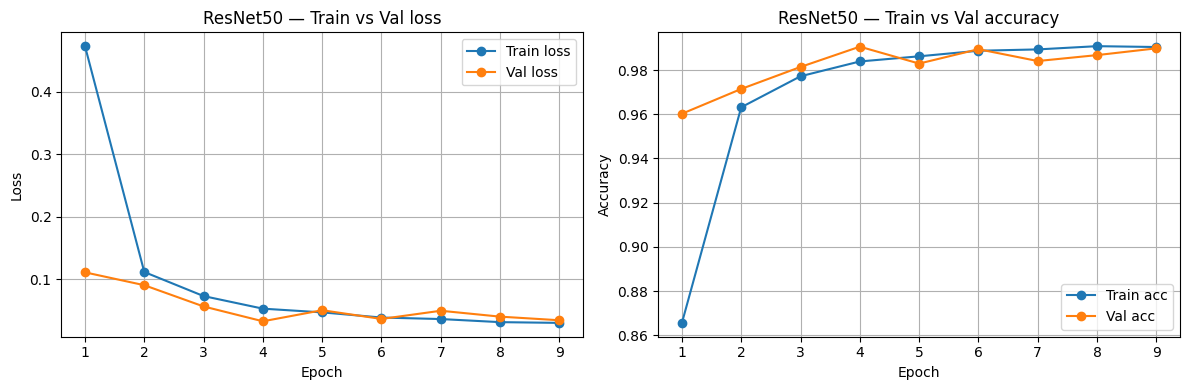

In [14]:
resnet_model, resnet_history = train_model(resnet_model, "ResNet50", max_epochs=40, patience=5)
plot_history(resnet_history, "ResNet50")
torch.save(resnet_model.state_dict(), "/kaggle/working/resnet50_gtsrb.pth")


  Навчання: EfficientNet-B0
Epoch 1/40 | train_loss: 1.5497, train_acc: 0.5891 | val_loss: 0.6285, val_acc: 0.8168
Epoch 2/40 | train_loss: 0.5873, train_acc: 0.8280 | val_loss: 0.3232, val_acc: 0.8962
Epoch 3/40 | train_loss: 0.3925, train_acc: 0.8812 | val_loss: 0.2206, val_acc: 0.9296
Epoch 4/40 | train_loss: 0.2997, train_acc: 0.9064 | val_loss: 0.1731, val_acc: 0.9426
Epoch 5/40 | train_loss: 0.2396, train_acc: 0.9243 | val_loss: 0.1404, val_acc: 0.9513
Epoch 6/40 | train_loss: 0.2078, train_acc: 0.9337 | val_loss: 0.1226, val_acc: 0.9600
Epoch 7/40 | train_loss: 0.1804, train_acc: 0.9420 | val_loss: 0.1072, val_acc: 0.9648
Epoch 8/40 | train_loss: 0.1625, train_acc: 0.9477 | val_loss: 0.0981, val_acc: 0.9665
Epoch 9/40 | train_loss: 0.1399, train_acc: 0.9544 | val_loss: 0.0870, val_acc: 0.9714
Epoch 10/40 | train_loss: 0.1293, train_acc: 0.9585 | val_loss: 0.0815, val_acc: 0.9711
Epoch 11/40 | train_loss: 0.1161, train_acc: 0.9632 | val_loss: 0.0810, val_acc: 0.9712
Epoch 12/40 

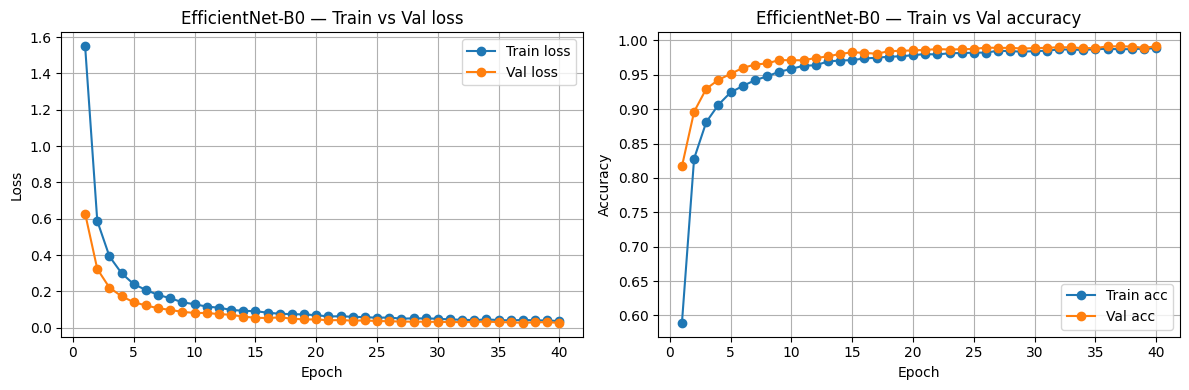

In [15]:
effnet_model, effnet_history = train_model(
    effnet_model, "EfficientNet-B0",
    max_epochs=40, patience=5
)
plot_history(effnet_history, "EfficientNet-B0")
torch.save(effnet_model.state_dict(), "/kaggle/working/efficientnet_b0_gtsrb.pth")

In [16]:
test_df = pd.read_csv(TEST_CSV)
print(test_df.head())
print("Test samples:", len(test_df))

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png
Test samples: 12630


In [17]:
class GTSRBTestDataset(Dataset):
    def __init__(self, df, base_dir, class_id_to_idx, transform=None, use_roi=True):
        self.df             = df.reset_index(drop=True)
        self.base_dir       = base_dir
        self.transform      = transform
        self.class_id_to_idx = class_id_to_idx
        self.use_roi        = use_roi

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.base_dir, row["Path"])
        img      = Image.open(img_path).convert("RGB")

        if self.use_roi:
            x1, y1 = int(row["Roi.X1"]), int(row["Roi.Y1"])
            x2, y2 = int(row["Roi.X2"]), int(row["Roi.Y2"])
            img    = img.crop((x1, y1, x2, y2))

        label = self.class_id_to_idx[int(row["ClassId"])]

        if self.transform:
            img = self.transform(img)

        return img, label

test_dataset = GTSRBTestDataset(
    test_df, BASE_DIR,
    class_id_to_idx=id_to_internal,
    transform=eval_transform,
    use_roi=True
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [18]:
def evaluate_model(model, model_name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy = accuracy_score(all_labels, all_preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    print(f"\n── {model_name} ──────────────────────────")
    print(f"Accuracy:          {accuracy:.4f}")
    print(f"Precision (macro): {precision_macro:.4f}")
    print(f"Recall (macro):    {recall_macro:.4f}")
    print(f"F1-score (macro):  {f1_macro:.4f}")

    class_names = train_full.classes
    print("\nClassification report:")
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names, zero_division=0
    ))

   
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 10))
    im = plt.imshow(cm, interpolation="nearest")
    plt.title(f"{model_name} — Confusion matrix")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

   
    metrics_names  = ["Accuracy", "Precision", "Recall", "F1-score"]
    metrics_values = [accuracy, precision_macro, recall_macro, f1_macro]
    plt.figure(figsize=(6, 4))
    plt.bar(metrics_names, metrics_values)
    plt.ylim(0, 1.0)
    plt.title(f"{model_name} — Global metrics (macro)")
    for i, v in enumerate(metrics_values):
        plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
    plt.tight_layout()
    plt.show()

    return {
        "model":     model_name,
        "accuracy":  accuracy,
        "precision": precision_macro,
        "recall":    recall_macro,
        "f1":        f1_macro,
    }


── BaselineCNN ──────────────────────────
Accuracy:          0.7302
Precision (macro): 0.7326
Recall (macro):    0.6447
F1-score (macro):  0.6343

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.07      0.12        60
           1       0.39      0.88      0.55       720
          10       0.98      0.95      0.97       660
          11       0.62      0.95      0.75       420
          12       0.85      0.93      0.89       690
          13       0.69      0.99      0.81       720
          14       0.91      0.87      0.89       270
          15       0.85      0.57      0.68       210
          16       0.73      0.96      0.83       150
          17       0.97      0.81      0.88       360
          18       0.92      0.78      0.85       390
          19       0.59      0.80      0.68        60
           2       0.79      0.35      0.49       750
          20       0.49      0.38      0.43        90
          21      

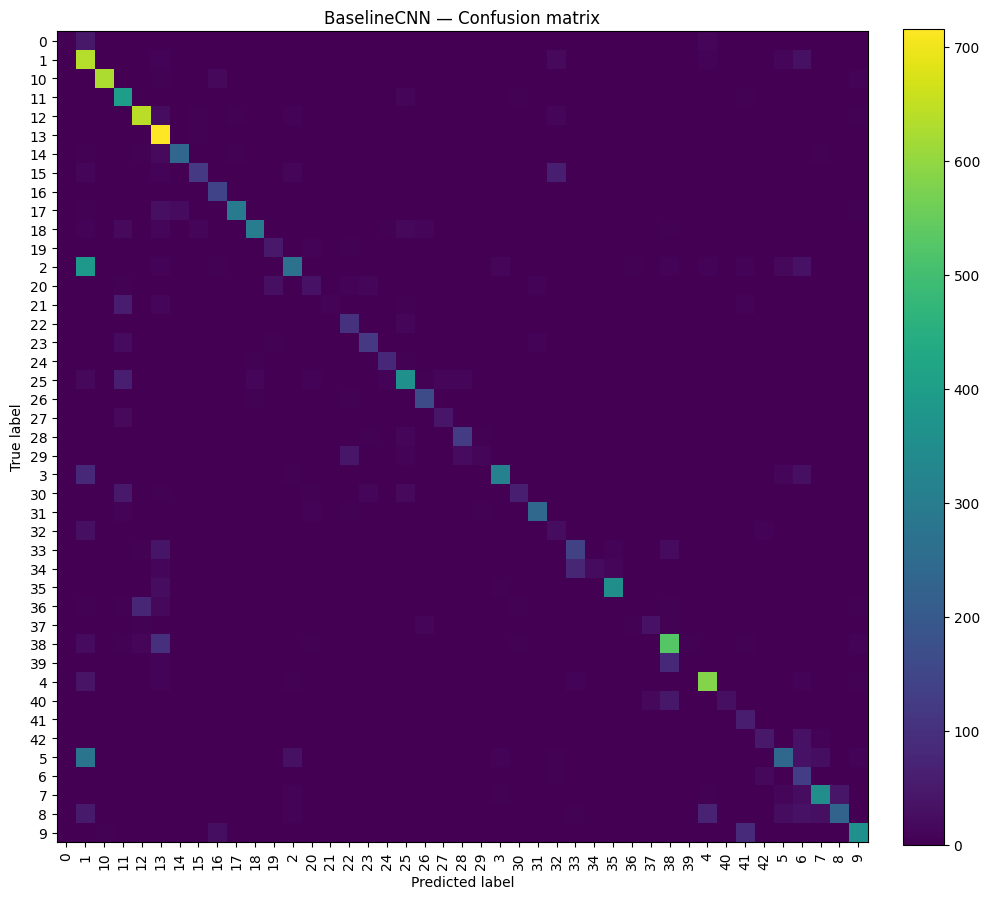

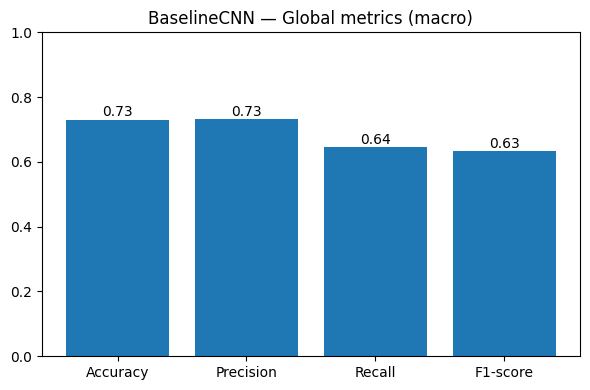

In [19]:
results_baseline = evaluate_model(baseline_model, "BaselineCNN")


── ResNet50 ──────────────────────────
Accuracy:          0.8841
Precision (macro): 0.8424
Recall (macro):    0.8433
F1-score (macro):  0.8343

Classification report:
              precision    recall  f1-score   support

           0       0.63      0.87      0.73        60
           1       0.81      0.92      0.86       720
          10       0.98      1.00      0.99       660
          11       0.86      0.99      0.92       420
          12       1.00      0.91      0.95       690
          13       0.95      0.98      0.97       720
          14       1.00      0.90      0.95       270
          15       0.88      0.98      0.93       210
          16       0.99      0.95      0.97       150
          17       0.96      0.91      0.94       360
          18       0.93      0.93      0.93       390
          19       0.44      0.60      0.51        60
           2       0.88      0.92      0.90       750
          20       0.54      0.57      0.55        90
          21       0.

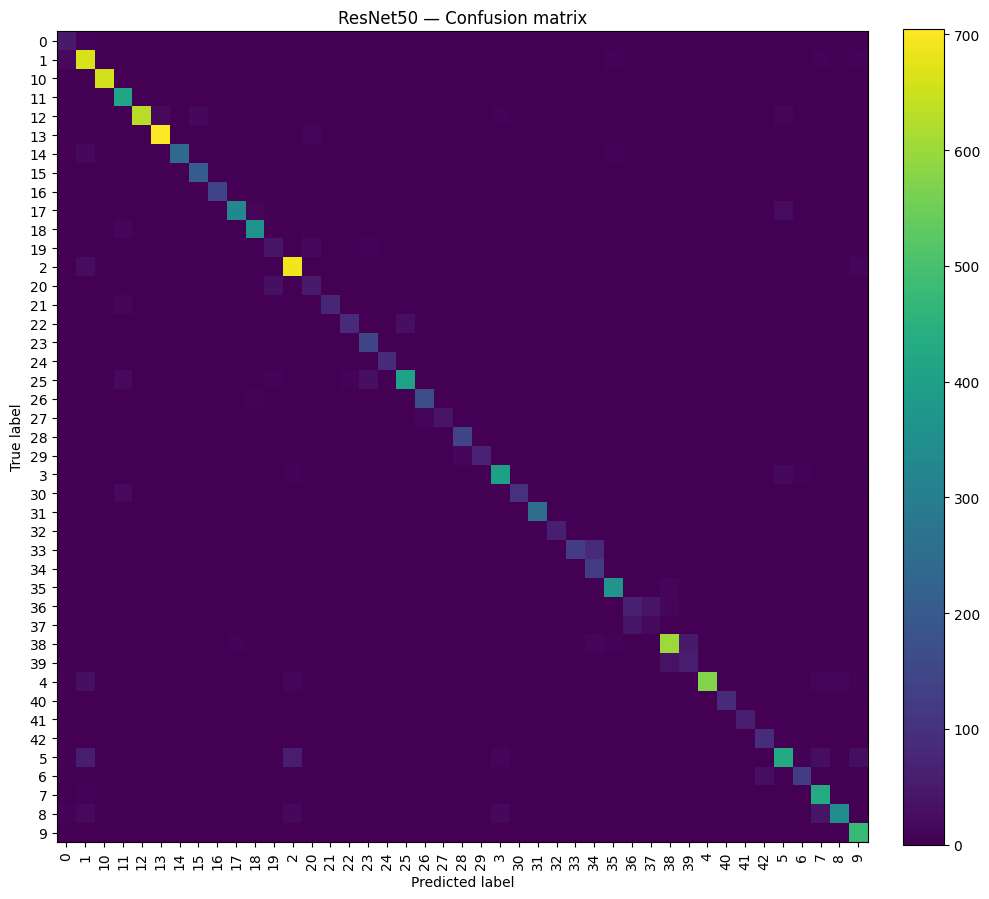

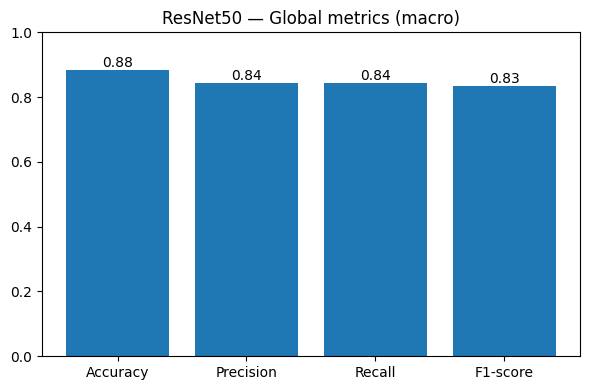

In [20]:
results_resnet = evaluate_model(resnet_model, "ResNet50")


── EfficientNet-B0 ──────────────────────────
Accuracy:          0.8415
Precision (macro): 0.8122
Recall (macro):    0.7826
F1-score (macro):  0.7814

Classification report:
              precision    recall  f1-score   support

           0       0.26      0.38      0.31        60
           1       0.79      0.81      0.80       720
          10       0.97      0.95      0.96       660
          11       0.73      0.95      0.82       420
          12       1.00      0.94      0.97       690
          13       0.94      0.98      0.96       720
          14       1.00      0.89      0.94       270
          15       1.00      0.92      0.96       210
          16       0.67      0.99      0.80       150
          17       0.86      0.95      0.90       360
          18       0.97      0.89      0.93       390
          19       0.56      0.97      0.71        60
           2       0.63      0.91      0.75       750
          20       0.63      0.47      0.54        90
          21  

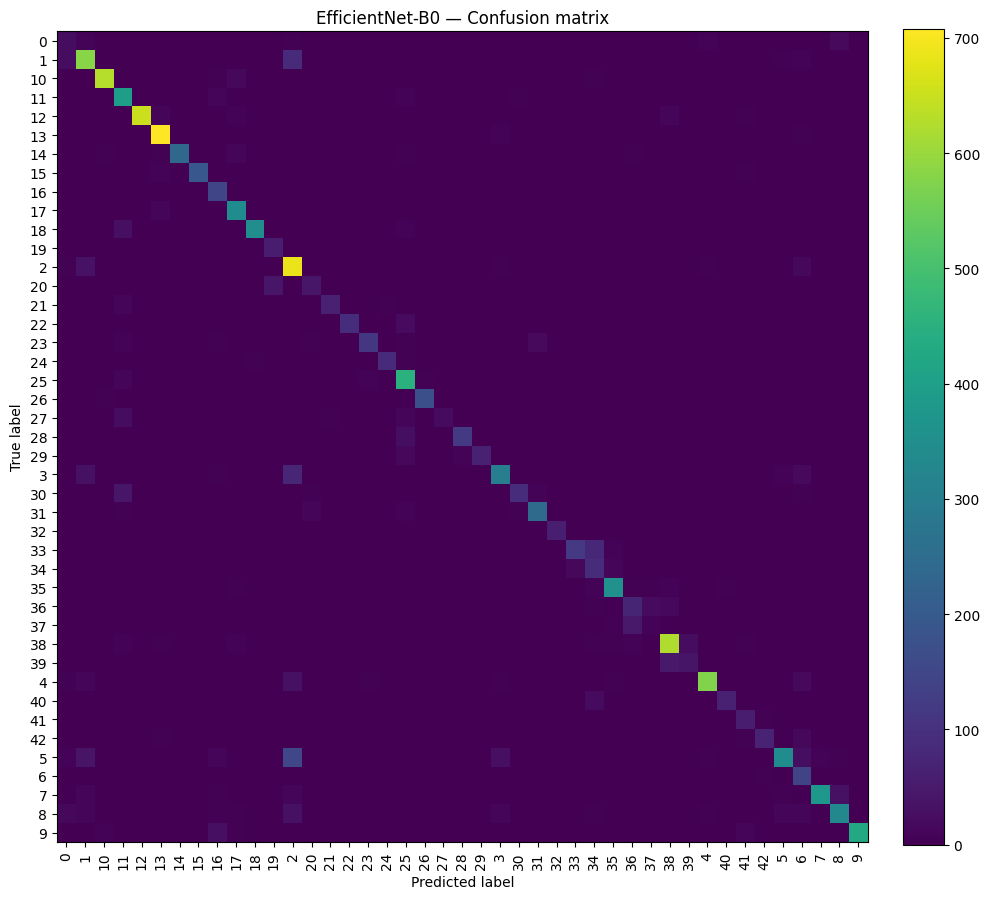

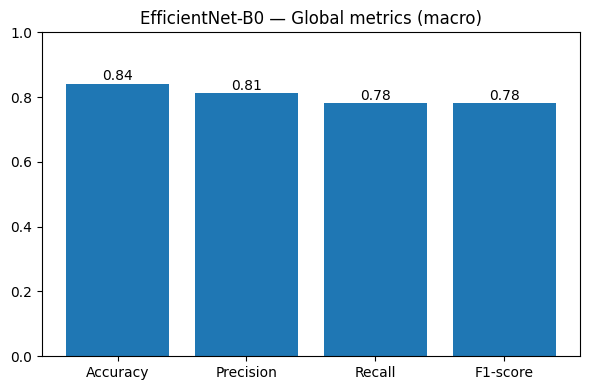

In [21]:
results_effnet = evaluate_model(effnet_model, "EfficientNet-B0")

In [22]:
results_df = pd.DataFrame([
    results_baseline,
    results_resnet,
    results_effnet,
])

print("\n" + "="*55)
print("  ПІДСУМКОВІ РЕЗУЛЬТАТИ CNN")
print("="*55)
print(results_df.to_string(index=False))

results_df.to_csv("/kaggle/working/cnn_results_summary.csv", index=False)


  ПІДСУМКОВІ РЕЗУЛЬТАТИ CNN
          model  accuracy  precision   recall       f1
    BaselineCNN  0.730245   0.732625 0.644657 0.634288
       ResNet50  0.884086   0.842364 0.843309 0.834344
EfficientNet-B0  0.841489   0.812179 0.782608 0.781435

Схеровано: /kaggle/working/cnn_results_summary.csv



── BaselineCNN ──


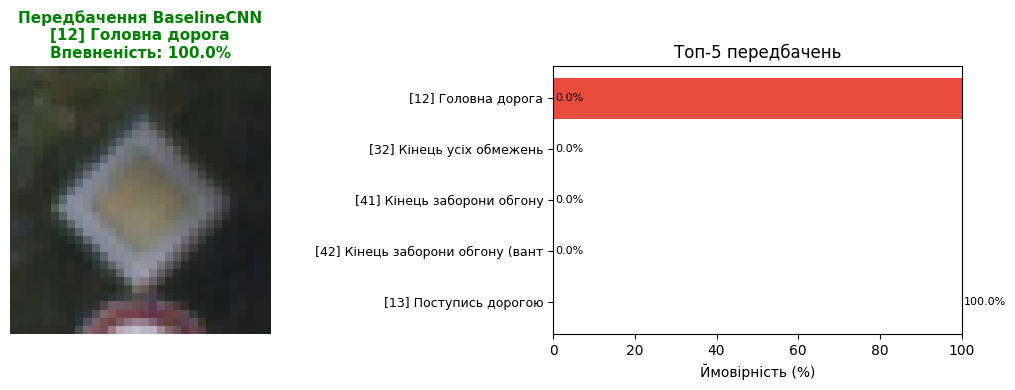


────────────────────────────────────────────────
  Модель      : BaselineCNN
  Клас ID     : 12
  Назва       : Головна дорога
  Впевненість : 100.00%
────────────────────────────────────────────────

── ResNet50 ──


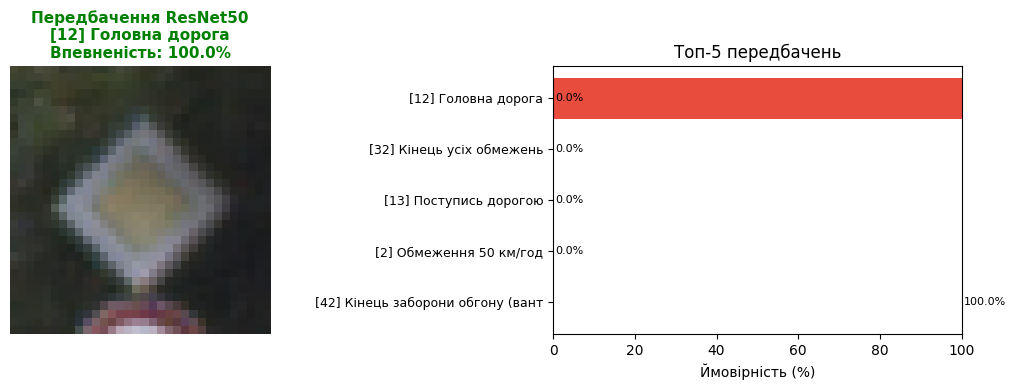


────────────────────────────────────────────────
  Модель      : ResNet50
  Клас ID     : 12
  Назва       : Головна дорога
  Впевненість : 99.99%
────────────────────────────────────────────────

── EfficientNet-B0 ──


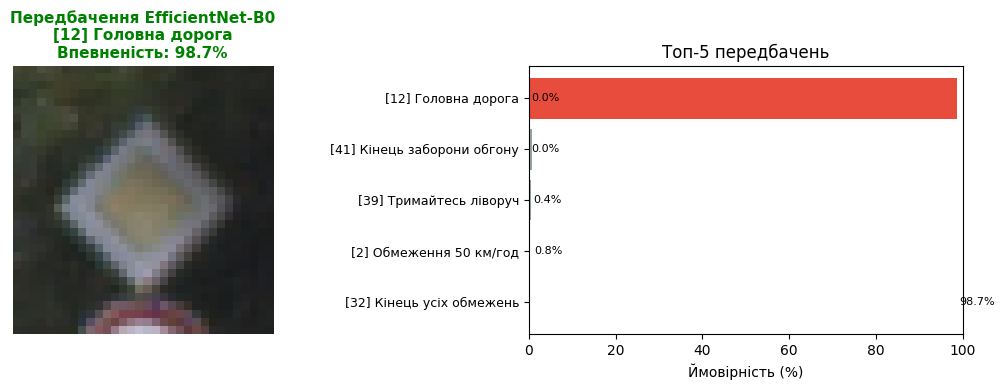


────────────────────────────────────────────────
  Модель      : EfficientNet-B0
  Клас ID     : 12
  Назва       : Головна дорога
  Впевненість : 98.71%
────────────────────────────────────────────────


(12, 'Головна дорога', 0.9870523810386658)

In [23]:
import torch.nn.functional as F
from PIL import Image

CLASS_NAMES = {
    0:  "Обмеження 20 км/год",      1:  "Обмеження 30 км/год",
    2:  "Обмеження 50 км/год",      3:  "Обмеження 60 км/год",
    4:  "Обмеження 70 км/год",      5:  "Обмеження 80 км/год",
    6:  "Кінець обмеження 80",      7:  "Обмеження 100 км/год",
    8:  "Обмеження 120 км/год",     9:  "Заборона обгону",
    10: "Заборона обгону (вант.)",  11: "Пріоритет на перехресті",
    12: "Головна дорога",           13: "Поступись дорогою",
    14: "Стоп",                     15: "Рух заборонено",
    16: "Вант. транспорт заборон.", 17: "В'їзд заборонено",
    18: "Увага",                    19: "Небезп. поворот ліворуч",
    20: "Небезп. поворот праворуч", 21: "Подвійний поворот",
    22: "Нерівна дорога",           23: "Слизька дорога",
    24: "Звуження праворуч",        25: "Дорожні роботи",
    26: "Світлофор",                27: "Пішохідний перехід",
    28: "Діти",                     29: "Велосипедисти",
    30: "Ожеледиця/сніг",           31: "Дикі тварини",
    32: "Кінець усіх обмежень",     33: "Поворот праворуч",
    34: "Поворот ліворуч",          35: "Прямо обов'язково",
    36: "Прямо або праворуч",       37: "Прямо або ліворуч",
    38: "Тримайтесь праворуч",      39: "Тримайтесь ліворуч",
    40: "Кільцевий рух",            41: "Кінець заборони обгону",
    42: "Кінець заборони обгону (вант.)",
}

internal_to_id = {v: k for k, v in id_to_internal.items()}

def predict_single_cnn(image_path, model, model_name, top_k=5):
    img = Image.open(image_path).convert("RGB")
    tensor = eval_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1)[0]   # [43]

    top_probs, top_idxs = torch.topk(probs, top_k)
    top_probs = top_probs.cpu().numpy()
    top_ids   = [internal_to_id[i.item()] for i in top_idxs]
    top_names = [CLASS_NAMES.get(cid, f"Клас {cid}") for cid in top_ids]

    best_id   = top_ids[0]
    best_name = top_names[0]
    best_conf = float(top_probs[0])

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].imshow(img)
    axes[0].axis("off")
    color = "green" if best_conf > 0.7 else "orange"
    axes[0].set_title(
        f"Передбачення {model_name}\n[{best_id}] {best_name}\nВпевненість: {best_conf:.1%}",
        fontsize=11, fontweight="bold", color=color
    )

    bars = axes[1].barh(
        range(top_k - 1, -1, -1),
        top_probs * 100,
        color=["#e74c3c" if i == 0 else "#95a5a6" for i in range(top_k)]
    )
    labels_short = [f"[{cid}] {nm[:28]}" for cid, nm in zip(top_ids, top_names)]
    axes[1].set_yticks(range(top_k - 1, -1, -1))
    axes[1].set_yticklabels(labels_short, fontsize=9)
    axes[1].set_xlabel("Ймовірність (%)")
    axes[1].set_xlim(0, 100)
    axes[1].set_title(f"Топ-{top_k} передбачень")
    for bar, val in zip(bars, top_probs[::-1]):
        axes[1].text(val * 100 + 0.5, bar.get_y() + bar.get_height()/2,
                     f"{val:.1%}", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"\n{'─'*48}")
    print(f"  Модель      : {model_name}")
    print(f"  Клас ID     : {best_id}")
    print(f"  Назва       : {best_name}")
    print(f"  Впевненість : {best_conf:.2%}")
    print(f"{'─'*48}")
    return best_id, best_name, best_conf


IMAGE_PATH = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test/00007.png"

print("\n── BaselineCNN ──")
predict_single_cnn(IMAGE_PATH, baseline_model, "BaselineCNN")

print("\n── ResNet50 ──")
predict_single_cnn(IMAGE_PATH, resnet_model, "ResNet50")

print("\n── EfficientNet-B0 ──")
predict_single_cnn(IMAGE_PATH, effnet_model, "EfficientNet-B0")


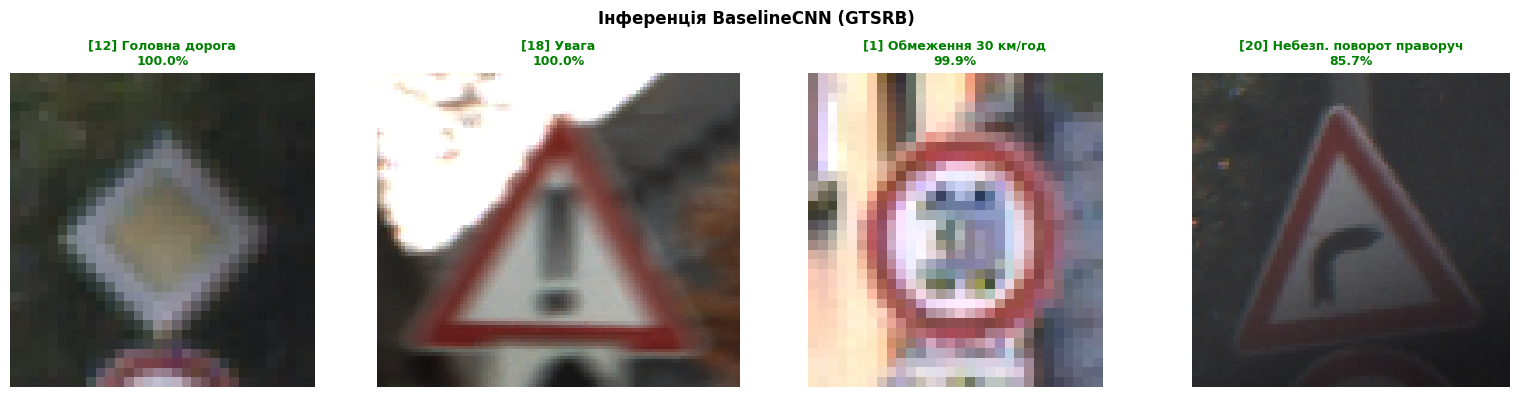

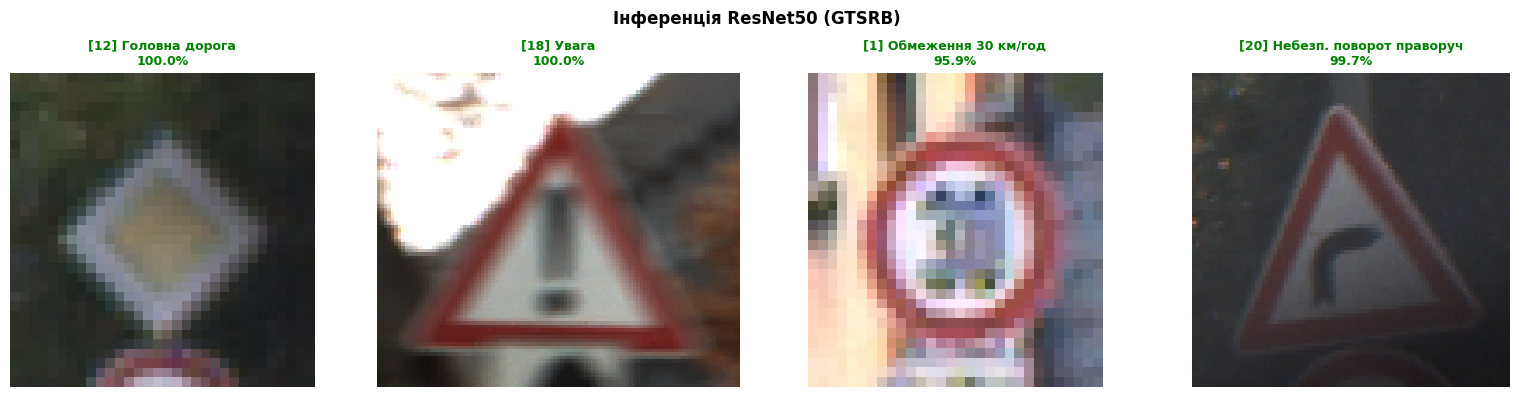

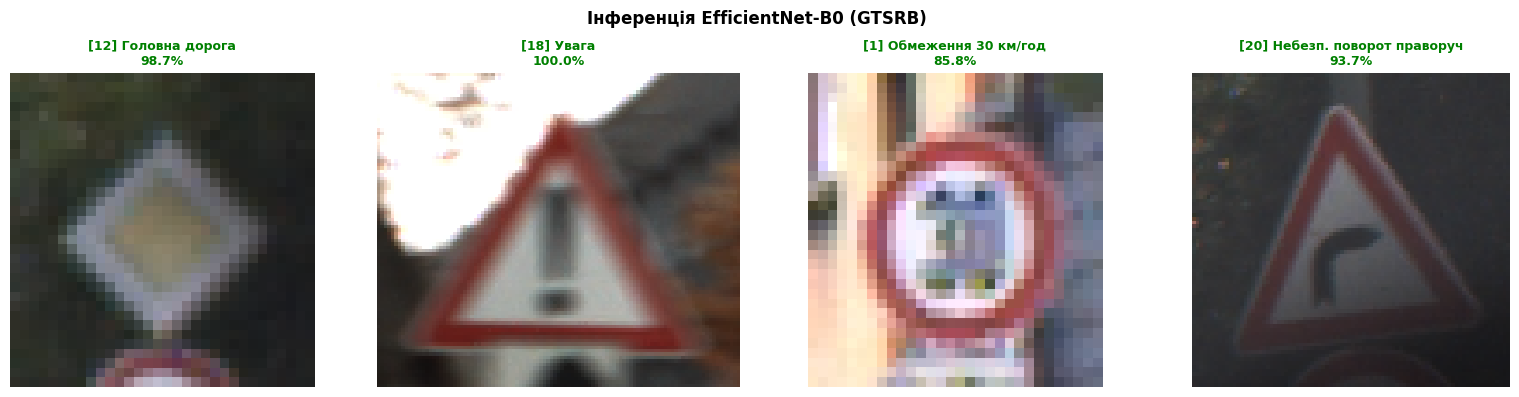

In [24]:
def predict_grid_cnn(image_paths, model, model_name):
    n = len(image_paths)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    model.eval()
    for ax, path in zip(axes, image_paths):
        img = Image.open(path).convert("RGB")
        tensor = eval_transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            probs = F.softmax(model(tensor), dim=1)[0]

        top_prob, top_idx = probs.max(0)
        class_id = internal_to_id[top_idx.item()]
        name     = CLASS_NAMES.get(class_id, f"Клас {class_id}")
        conf     = top_prob.item()

        ax.imshow(img)
        ax.axis("off")
        color = "green" if conf > 0.7 else "orange"
        ax.set_title(f"[{class_id}] {name}\n{conf:.1%}",
                     fontsize=9, color=color, fontweight="bold")

    plt.suptitle(f"Інференція {model_name} (GTSRB)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


test_samples = [
    "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test/00007.png",
    "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test/00042.png",
    "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test/00100.png",
    "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test/00250.png",
]

predict_grid_cnn(test_samples, baseline_model,  "BaselineCNN")
predict_grid_cnn(test_samples, resnet_model,    "ResNet50")
predict_grid_cnn(test_samples, effnet_model,    "EfficientNet-B0")



  ПОРІВНЯННЯ CNN-МОДЕЛЕЙ
  BaselineCNN       : [12] Головна дорога                      100.00%
  ResNet50          : [12] Головна дорога                      99.99%
  EfficientNet-B0   : [12] Головна дорога                      98.71%


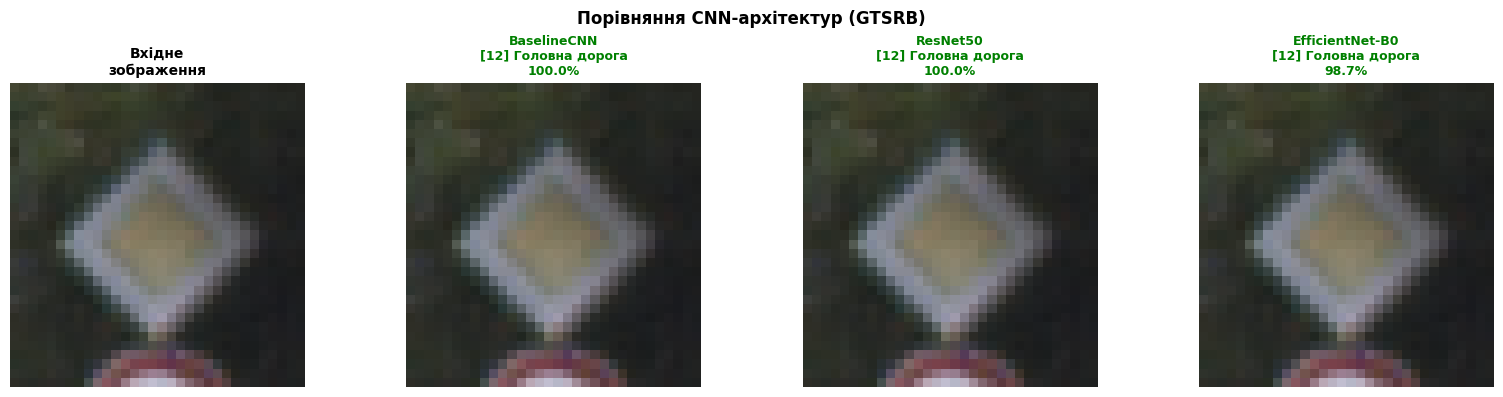

In [25]:
def compare_all_cnn(image_path):
    models_dict = {
        "BaselineCNN":     baseline_model,
        "ResNet50":        resnet_model,
        "EfficientNet-B0": effnet_model,
    }
    img = Image.open(image_path).convert("RGB")
    tensor = eval_transform(img).unsqueeze(0).to(device)

    n = len(models_dict)
    fig, axes = plt.subplots(1, n + 1, figsize=(4 * (n + 1), 4))

    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title("Вхідне\nзображення", fontsize=10, fontweight="bold")

    print(f"\n{'='*55}")
    print(f"  ПОРІВНЯННЯ CNN-МОДЕЛЕЙ")
    print(f"{'='*55}")

    for ax, (name, mdl) in zip(axes[1:], models_dict.items()):
        mdl.eval()
        with torch.no_grad():
            probs = F.softmax(mdl(tensor), dim=1)[0]

        top_prob, top_idx = probs.max(0)
        class_id = internal_to_id[top_idx.item()]
        label    = CLASS_NAMES.get(class_id, f"Клас {class_id}")
        conf     = top_prob.item()

        color = "green" if conf > 0.7 else "orange"
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{name}\n[{class_id}] {label[:18]}\n{conf:.1%}",
                     fontsize=9, color=color, fontweight="bold")

        print(f"  {name:<18}: [{class_id:2d}] {label:<35} {conf:.2%}")

    print(f"{'='*55}")
    plt.suptitle("Порівняння CNN-архітектур (GTSRB)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


IMAGE_PATH = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test/00007.png"
compare_all_cnn(IMAGE_PATH)
